In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

mapping the folders 

In [1]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes")

print(f"Dataset downloaded to: {path}")

# List the main folders (usually Train, Val, Test)
subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
print(f"Main Subfolders: {subfolders}")

# Let's peek into the 'Train' folder to see the classes
train_path = os.path.join(path, "Train")
classes = [c for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))]
print(f"Detected Tumor Classes: {classes}")

Dataset downloaded to: /kaggle/input/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
Main Subfolders: ['Val', 'Train']
Detected Tumor Classes: ['Pituitary', 'No Tumor', 'Meningioma', 'Glioma']


the deep dive inspector 

In [2]:
import pandas as pd

stats = []
for split in ['Train', 'Val']:
    split_path = os.path.join(path, split)
    for tumor_type in os.listdir(split_path):
        class_path = os.path.join(split_path, tumor_type)
        if os.path.isdir(class_path):
            img_count = len(os.listdir(os.path.join(class_path, 'images')))
            lbl_count = len(os.listdir(os.path.join(class_path, 'labels')))
            stats.append({
                "Split": split,
                "Tumor Type": tumor_type,
                "Images": img_count,
                "Labels": lbl_count
            })

df_stats = pd.DataFrame(stats)
print("\n--- Dataset Summary ---")
print(df_stats)


--- Dataset Summary ---
   Split  Tumor Type  Images  Labels
0  Train   Pituitary    1424    1424
1  Train    No Tumor     711     711
2  Train  Meningioma    1449    1449
3  Train      Glioma    1153    1153
4    Val   Pituitary     136     136
5    Val    No Tumor     100     100
6    Val  Meningioma     140     140
7    Val      Glioma     136     136


visualising a sample 

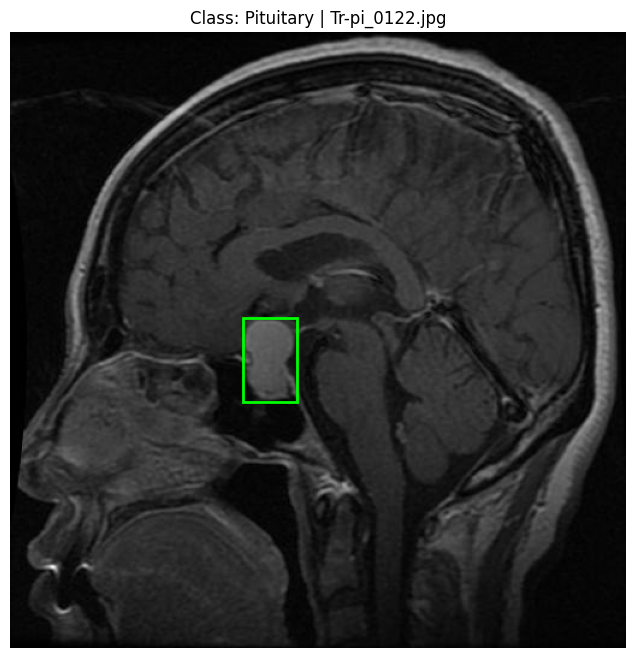

In [3]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def peek_at_data(data_path):
    # Pick a random class from Train
    train_path = os.path.join(data_path, "Train")
    target_class = random.choice([c for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))])
    
    img_dir = os.path.join(train_path, target_class, "images")
    lbl_dir = os.path.join(train_path, target_class, "labels")
    
    # Get a random image
    img_file = random.choice(os.listdir(img_dir))
    img_path = os.path.join(img_dir, img_file)
    lbl_path = os.path.join(lbl_dir, img_file.replace('.jpg', '.txt')) # Assuming .jpg
    
    # Load Image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    
    # Create plot
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    ax.set_title(f"Class: {target_class} | {img_file}")
    
    # Draw Box if label exists
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                # YOLO format: class x_center y_center width height
                _, x_c, y_c, bw, bh = map(float, line.split())
                
                # Convert normalized to pixel coordinates
                x = (x_c - bw/2) * w
                y = (y_c - bh/2) * h
                rect_w = bw * w
                rect_h = bh * h
                
                rect = patches.Rectangle((x, y), rect_w, rect_h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()

peek_at_data(path)

pre processing 

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def min_max_normalize(image):
    image = image.astype(np.float32)
    if image.max() - image.min() == 0: 
        return np.zeros_like(image)
    return (image - image.min()) / (image.max() - image.min())

def apply_clahe(image):
    # If image is RGB, convert to Gray for CLAHE
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Normalize to 0-1 range
    image = min_max_normalize(image)
    
    # Convert to 8-bit for OpenCV CLAHE
    image_uint8 = (image * 255).astype(np.uint8)
    
    # Create CLAHE object
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image_uint8)
    
    # Return as normalized float32
    return enhanced.astype(np.float32) / 255.0

comparing original vs clahe // no need to run this one over and over again in every new run time 

Found image: /kaggle/input/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes/Train/Pituitary/images/Tr-pi_0282.jpg


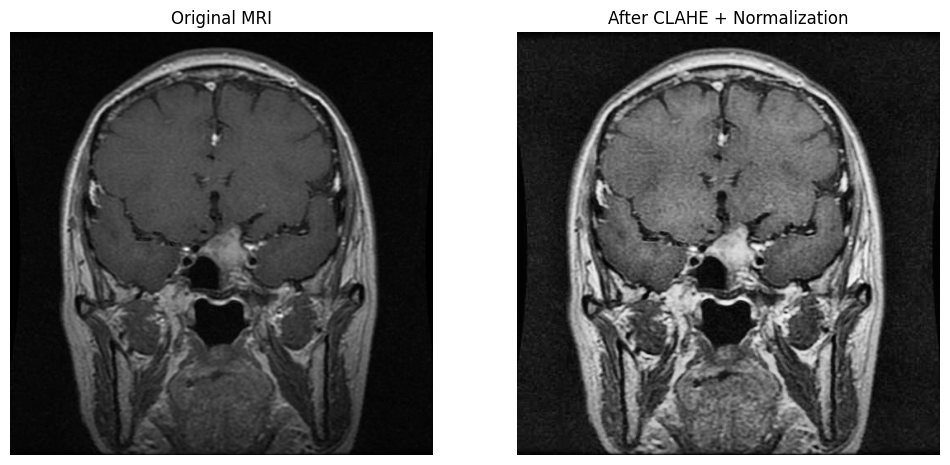

In [5]:
def compare_preprocessing(img_path):
    orig_bgr = cv2.imread(img_path)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    
    # Apply your processing
    processed = apply_clahe(orig_rgb)
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(orig_rgb)
    plt.title("Original MRI")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(processed, cmap='gray')
    plt.title("After CLAHE + Normalization")
    plt.axis('off')
    
    plt.show()
import os

def test_first_available_image(base_path):
    # This looks for the first .jpg file it can find in the Train folder
    for root, dirs, files in os.walk(os.path.join(base_path, "Train")):
        for file in files:
            if file.lower().endswith(".jpg"):
                full_path = os.path.join(root, file)
                print(f"Found image: {full_path}")
                compare_preprocessing(full_path)
                return # Stop after the first one!
    print("No images found. Is the download finished?")

# Run this instead
test_first_available_image(path)
# Test it on one image (ensure 'path' is defined from previous steps)
# sample_img = os.path.join(path, "Train/Glioma/images/gg (1).jpg")
# compare_preprocessing(sample_img)

tranform for training 

In [5]:
import torch
import torchvision.transforms as T

class MRIEnhancedTransform:
    def __init__(self, augment=False):
        self.augment = augment
        self.resize = T.Resize((224, 224))
        self.aug_pipeline = T.Compose([
            T.RandomRotation(15),
            T.RandomHorizontalFlip(p=0.5)
        ])

    def __call__(self, img):
        # 1. Convert PIL image to numpy array
        img_np = np.array(img)
        
        # 2. Apply your CLAHE logic
        enhanced = apply_clahe(img_np)
        
        # 3. Convert back to Tensor (C, H, W)
        # We repeat to 3 channels because EfficientNet expects RGB-style input
        img_tensor = torch.tensor(enhanced).unsqueeze(0).repeat(3, 1, 1)
        
        # 4. Resize
        img_tensor = self.resize(img_tensor)
        
        # 5. Optional Augmentation (only for training)
        if self.augment:
            img_tensor = self.aug_pipeline(img_tensor)
            
        return img_tensor

identify the class names ()

In [6]:
import os
from torchvision import datasets

# Define paths
train_path = os.path.join(path, "Train")
val_path = os.path.join(path, "Val")

# Create the Datasets using your MRIEnhancedTransform
# Use augment=True for training to help the model generalize
# Use augment=False for validation to get a clean performance check
train_ds = datasets.ImageFolder(train_path, transform=MRIEnhancedTransform(augment=True))
val_ds = datasets.ImageFolder(val_path, transform=MRIEnhancedTransform(augment=False))

print(f"Classes found: {train_ds.classes}")
print(f"Training images: {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")

Classes found: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
Training images: 4737
Validation images: 512


handle class imbalance 

In [7]:
import torch

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [8]:
from collections import Counter
import torch

# Count how many images are in each class
counts = Counter(train_ds.targets)
class_weights = []

# Calculate weight: Total_Samples / (Number_of_Classes * Samples_in_Class)
for i in range(len(train_ds.classes)):
    weight = sum(counts.values()) / (len(counts) * counts[i])
    class_weights.append(weight)

weights_tensor = torch.tensor(class_weights).to(device)
print(f"Calculated weights: {class_weights}")

Calculated weights: [1.027103209019948, 0.817287784679089, 1.6656118143459915, 0.8316362359550562]


create dataloaders

In [9]:
from torch.utils.data import DataLoader

# Batch size of 32 is a good balance for GPU memory
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# Let's test a single batch to make sure it works
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}") # Should be [32, 3, 224, 224]

Batch shape: torch.Size([32, 3, 224, 224])


initialising the models 

In [12]:
import torch
import torch.nn as nn
from torchvision import models

def build_expert_model(model_type, num_classes=4):
    if model_type == 'resnet':
        # Loading ResNet50 (V2 weights)
        model = models.resnet50(weights='IMAGENET1K_V2')
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    elif model_type == 'mobilenet':
        model = models.mobilenet_v2(weights='DEFAULT')
        num_ftrs = model.last_channel # 1280
        model.classifier[1] = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    elif model_type == 'densenet':
        model = models.densenet121(weights='DEFAULT')
        num_ftrs = model.classifier.in_features # 1024
        model.classifier = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    # Freeze the backbone (Feature Extractor)
    for name, param in model.named_parameters():
        if "fc" not in name and "classifier" not in name:
            param.requires_grad = False
            
    return model.to(device)

# Initialize the three experts
resnet_expert = build_expert_model('resnet')
mobilenet_expert = build_expert_model('mobilenet')
densenet_expert = build_expert_model('densenet')

print("All three expert models loaded and pushed to GPU.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s] 


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 113MB/s] 


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 168MB/s] 


All three expert models loaded and pushed to GPU.


resnet 

phase 1, frozen back bone

In [13]:
# 1. Initialize the ResNet Expert (matching the paper's backbone choice)
resnet_expert = build_expert_model('resnet')

# 2. Run the training function we defined
print("Starting Phase 1: Training ResNet50 Classifier...")
train_individual_model(resnet_expert, "resnet50", epochs=10)

Starting Phase 1: Training ResNet50 Classifier...
Epoch 1/10 | train | Loss: 0.5998 Acc: 0.7634
Epoch 1/10 | val   | Loss: 0.6258 Acc: 0.7500
Epoch 2/10 | train | Loss: 0.4137 Acc: 0.8303
Epoch 2/10 | val   | Loss: 0.3969 Acc: 0.8496
Epoch 3/10 | train | Loss: 0.3717 Acc: 0.8510
Epoch 3/10 | val   | Loss: 0.3308 Acc: 0.8906
Epoch 4/10 | train | Loss: 0.3333 Acc: 0.8640
Epoch 4/10 | val   | Loss: 0.2966 Acc: 0.9004
Epoch 5/10 | train | Loss: 0.3003 Acc: 0.8746
Epoch 5/10 | val   | Loss: 0.3176 Acc: 0.9043
Epoch 6/10 | train | Loss: 0.2913 Acc: 0.8809
Epoch 6/10 | val   | Loss: 0.2957 Acc: 0.8906
Epoch 7/10 | train | Loss: 0.2775 Acc: 0.8841
Epoch 7/10 | val   | Loss: 0.2718 Acc: 0.9043
Epoch 8/10 | train | Loss: 0.3023 Acc: 0.8752
Epoch 8/10 | val   | Loss: 0.2829 Acc: 0.9023
Epoch 9/10 | train | Loss: 0.2680 Acc: 0.8854
Epoch 9/10 | val   | Loss: 0.2449 Acc: 0.9277
Epoch 10/10 | train | Loss: 0.2638 Acc: 0.8932
Epoch 10/10 | val   | Loss: 0.2565 Acc: 0.9023
Training Complete. Best Accu

havent run the bolow cell, will go with it later

In [10]:
import torch.optim as optim

def train_individual_model(model, model_name, epochs=15):
    # Use the weights we calculated earlier for class imbalance
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    # Optimizer - starts with a higher learning rate for the head
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Scheduler to reduce LR if validation loss stalls
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)

    best_acc = 0.0
    
    for epoch in range(epochs):
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0
            
            loader = train_loader if phase == 'train' else val_loader
            dataset_size = len(train_ds) if phase == 'train' else len(val_ds)

            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            print(f'Epoch {epoch+1}/{epochs} | {phase:5} | Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), f'best_{model_name}.pth')
    
    print(f"Training Complete. Best Accuracy for {model_name}: {best_acc:.4f}")

# Start with ResNet50
print("Starting Phase 1: Training ResNet50 Classifier...")
train_individual_model(resnet_expert, "resnet50", epochs=10)

Starting Phase 1: Training ResNet50 Classifier...


NameError: name 'resnet_expert' is not defined

classification report, confusion matrix 

--- ResNet50 Classification Report ---
              precision    recall  f1-score   support

      Glioma       0.82      0.94      0.88       136
  Meningioma       0.92      0.73      0.81       140
    No Tumor       0.95      0.98      0.97       100
   Pituitary       0.94      0.99      0.96       136

    accuracy                           0.90       512
   macro avg       0.91      0.91      0.90       512
weighted avg       0.91      0.90      0.90       512



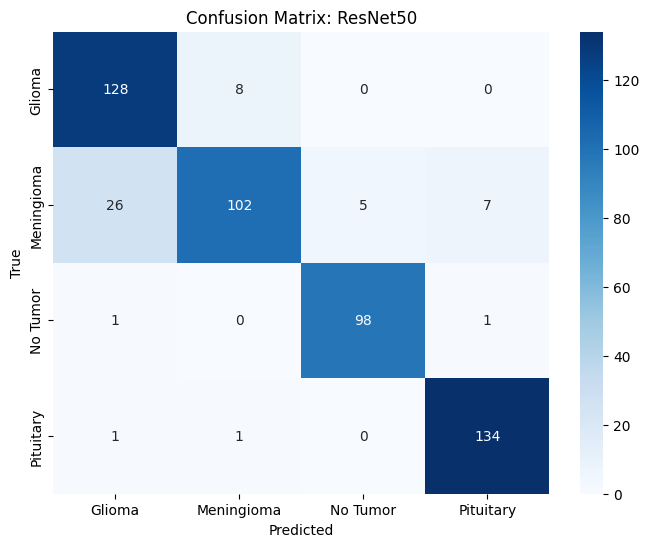

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_expert(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Classification Report (Precision, Recall, F1)
    print(f"--- {model_name} Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=train_ds.classes))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=train_ds.classes, yticklabels=train_ds.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

evaluate_expert(resnet_expert, val_loader, "ResNet50")

un freezing 

In [15]:
# Phase 2: Unfreeze the final layers for domain-specific fine-tuning
# We unfreeze 'layer4' and the 'fc' (classifier)
for name, param in resnet_expert.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Use a MUCH smaller learning rate (10x smaller) to avoid 'catastrophic forgetting'
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, resnet_expert.parameters()), lr=0.0001)

print("Phase 2: Last block unfrozen. Ready for fine-tuning.")

Phase 2: Last block unfrozen. Ready for fine-tuning.


fine tuning 

In [16]:
import torch.optim as optim

# 1. Unfreeze the last convolutional block (Layer 4) + the classifier (FC)
for name, param in resnet_expert.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2. Define a smaller learning rate for fine-tuning (Paper Theory)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, resnet_expert.parameters()), lr=0.0001)

# 3. Resume training with the new optimizer
print("Starting Phase 2: Fine-tuning ResNet50 Block 4...")
train_individual_model(resnet_expert, "resnet50_finetuned", epochs=10)

Starting Phase 2: Fine-tuning ResNet50 Block 4...
Epoch 1/10 | train | Loss: 0.2265 Acc: 0.9147
Epoch 1/10 | val   | Loss: 0.1176 Acc: 0.9707
Epoch 2/10 | train | Loss: 0.1173 Acc: 0.9544
Epoch 2/10 | val   | Loss: 0.0913 Acc: 0.9707
Epoch 3/10 | train | Loss: 0.0675 Acc: 0.9713
Epoch 3/10 | val   | Loss: 0.1689 Acc: 0.9766
Epoch 4/10 | train | Loss: 0.0704 Acc: 0.9713
Epoch 4/10 | val   | Loss: 0.0677 Acc: 0.9746
Epoch 5/10 | train | Loss: 0.0679 Acc: 0.9755
Epoch 5/10 | val   | Loss: 0.0923 Acc: 0.9746
Epoch 6/10 | train | Loss: 0.0690 Acc: 0.9749
Epoch 6/10 | val   | Loss: 0.3132 Acc: 0.9570
Epoch 7/10 | train | Loss: 0.0450 Acc: 0.9835
Epoch 7/10 | val   | Loss: 0.1128 Acc: 0.9805
Epoch 8/10 | train | Loss: 0.0234 Acc: 0.9911
Epoch 8/10 | val   | Loss: 0.0757 Acc: 0.9902
Epoch 9/10 | train | Loss: 0.0165 Acc: 0.9949
Epoch 9/10 | val   | Loss: 0.1771 Acc: 0.9902
Epoch 10/10 | train | Loss: 0.0142 Acc: 0.9951
Epoch 10/10 | val   | Loss: 0.0574 Acc: 0.9922
Training Complete. Best Accu

classification report

--- ResNet50_FineTuned Final Classification Report ---
              precision    recall  f1-score   support

      Glioma       1.00      0.99      1.00       136
  Meningioma       0.98      0.99      0.99       140
    No Tumor       1.00      0.98      0.99       100
   Pituitary       0.99      1.00      1.00       136

    accuracy                           0.99       512
   macro avg       0.99      0.99      0.99       512
weighted avg       0.99      0.99      0.99       512



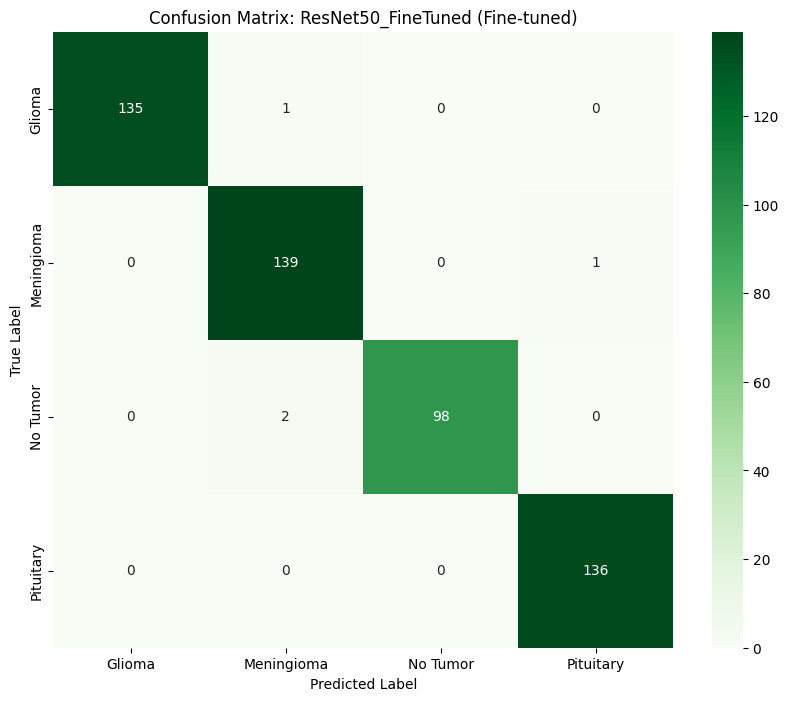

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_expert(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Print the text report
    print(f"--- {model_name} Final Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=train_ds.classes))
    
    # Plot the heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=train_ds.classes, yticklabels=train_ds.classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name} (Fine-tuned)')
    plt.show()

# Run the evaluation on your fine-tuned ResNet
evaluate_expert(resnet_expert, val_loader, "ResNet50_FineTuned")

meningoma 

In [18]:
# 1. Initialize the MobileNet Expert
mobilenet_expert = build_expert_model('mobilenet')

# 2. Phase 1: Train the Classifier only
print("Starting Phase 1: Training MobileNetV2 Classifier...")
train_individual_model(mobilenet_expert, "mobilenet_v2", epochs=10)

Starting Phase 1: Training MobileNetV2 Classifier...
Epoch 1/10 | train | Loss: 0.5780 Acc: 0.7636
Epoch 1/10 | val   | Loss: 0.3873 Acc: 0.8574
Epoch 2/10 | train | Loss: 0.4566 Acc: 0.8180
Epoch 2/10 | val   | Loss: 0.3223 Acc: 0.8691
Epoch 3/10 | train | Loss: 0.4084 Acc: 0.8320
Epoch 3/10 | val   | Loss: 0.3098 Acc: 0.8906
Epoch 4/10 | train | Loss: 0.3722 Acc: 0.8440
Epoch 4/10 | val   | Loss: 0.3725 Acc: 0.8477
Epoch 5/10 | train | Loss: 0.3816 Acc: 0.8431
Epoch 5/10 | val   | Loss: 0.2641 Acc: 0.9082
Epoch 6/10 | train | Loss: 0.3518 Acc: 0.8562
Epoch 6/10 | val   | Loss: 0.2585 Acc: 0.9043
Epoch 7/10 | train | Loss: 0.3498 Acc: 0.8552
Epoch 7/10 | val   | Loss: 0.2291 Acc: 0.9180
Epoch 8/10 | train | Loss: 0.3309 Acc: 0.8600
Epoch 8/10 | val   | Loss: 0.2223 Acc: 0.9141
Epoch 9/10 | train | Loss: 0.3068 Acc: 0.8664
Epoch 9/10 | val   | Loss: 0.1999 Acc: 0.9316
Epoch 10/10 | train | Loss: 0.3271 Acc: 0.8676
Epoch 10/10 | val   | Loss: 0.2730 Acc: 0.8906
Training Complete. Best A

--- mobile_netv2 Classification Report ---
              precision    recall  f1-score   support

      Glioma       0.99      0.99      0.99       136
  Meningioma       0.99      0.99      0.99       140
    No Tumor       1.00      0.99      0.99       100
   Pituitary       0.99      1.00      0.99       136

    accuracy                           0.99       512
   macro avg       0.99      0.99      0.99       512
weighted avg       0.99      0.99      0.99       512



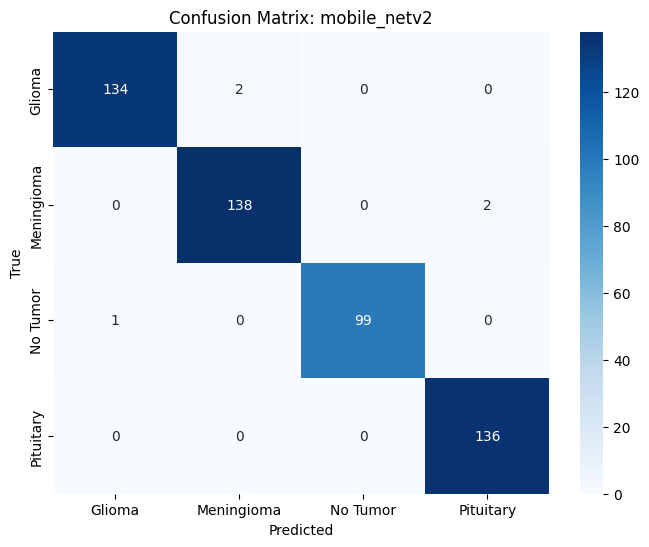

In [22]:
 from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_expert(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Classification Report (Precision, Recall, F1)
    print(f"--- {model_name} Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=train_ds.classes))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=train_ds.classes, yticklabels=train_ds.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

evaluate_expert(mobilenet_expert, val_loader, "mobile_netv2")

fine tuning the model 

In [20]:
# Phase 2 for MobileNetV2
# We unfreeze the last few convolutional layers (features[14] onwards) and the classifier
for name, param in mobilenet_expert.named_parameters():
    if "features.14" in name or "features.15" in name or "features.16" in name or "features.17" in name or "features.18" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Use the same low learning rate strategy from the ResNet success
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, mobilenet_expert.parameters()), lr=0.0001)

print("Phase 2: MobileNetV2 top blocks unfrozen. Starting fine-tuning...")
train_individual_model(mobilenet_expert, "mobilenet_v2_finetuned", epochs=10)

Phase 2: MobileNetV2 top blocks unfrozen. Starting fine-tuning...
Epoch 1/10 | train | Loss: 0.3161 Acc: 0.8767
Epoch 1/10 | val   | Loss: 0.2298 Acc: 0.9219
Epoch 2/10 | train | Loss: 0.1871 Acc: 0.9303
Epoch 2/10 | val   | Loss: 0.1071 Acc: 0.9609
Epoch 3/10 | train | Loss: 0.1434 Acc: 0.9460
Epoch 3/10 | val   | Loss: 0.3307 Acc: 0.8984
Epoch 4/10 | train | Loss: 0.1141 Acc: 0.9548
Epoch 4/10 | val   | Loss: 0.1168 Acc: 0.9590
Epoch 5/10 | train | Loss: 0.1011 Acc: 0.9635
Epoch 5/10 | val   | Loss: 0.1074 Acc: 0.9609
Epoch 6/10 | train | Loss: 0.0511 Acc: 0.9804
Epoch 6/10 | val   | Loss: 0.0332 Acc: 0.9863
Epoch 7/10 | train | Loss: 0.0407 Acc: 0.9818
Epoch 7/10 | val   | Loss: 0.0318 Acc: 0.9902
Epoch 8/10 | train | Loss: 0.0365 Acc: 0.9844
Epoch 8/10 | val   | Loss: 0.0217 Acc: 0.9941
Epoch 9/10 | train | Loss: 0.0396 Acc: 0.9861
Epoch 9/10 | val   | Loss: 0.0242 Acc: 0.9883
Epoch 10/10 | train | Loss: 0.0263 Acc: 0.9897
Epoch 10/10 | val   | Loss: 0.0204 Acc: 0.9902
Training Com

In [21]:
# 1. Initialize the DenseNet Expert
densenet_expert = build_expert_model('densenet')

# 2. Phase 1: Train the Classifier only
print("Starting Phase 1: Training DenseNet121 Classifier...")
train_individual_model(densenet_expert, "densenet121", epochs=10)

Starting Phase 1: Training DenseNet121 Classifier...
Epoch 1/10 | train | Loss: 0.6507 Acc: 0.7330
Epoch 1/10 | val   | Loss: 0.5286 Acc: 0.7734
Epoch 2/10 | train | Loss: 0.4643 Acc: 0.8140
Epoch 2/10 | val   | Loss: 0.4438 Acc: 0.8008
Epoch 3/10 | train | Loss: 0.4001 Acc: 0.8406
Epoch 3/10 | val   | Loss: 0.4390 Acc: 0.8184
Epoch 4/10 | train | Loss: 0.4128 Acc: 0.8311
Epoch 4/10 | val   | Loss: 0.3562 Acc: 0.8730
Epoch 5/10 | train | Loss: 0.3894 Acc: 0.8402
Epoch 5/10 | val   | Loss: 0.3316 Acc: 0.8672
Epoch 6/10 | train | Loss: 0.3439 Acc: 0.8621
Epoch 6/10 | val   | Loss: 0.2966 Acc: 0.8750
Epoch 7/10 | train | Loss: 0.3372 Acc: 0.8573
Epoch 7/10 | val   | Loss: 0.3583 Acc: 0.8516
Epoch 8/10 | train | Loss: 0.3324 Acc: 0.8594
Epoch 8/10 | val   | Loss: 0.3801 Acc: 0.8320
Epoch 9/10 | train | Loss: 0.3711 Acc: 0.8446
Epoch 9/10 | val   | Loss: 0.3086 Acc: 0.8691
Epoch 10/10 | train | Loss: 0.2753 Acc: 0.8873
Epoch 10/10 | val   | Loss: 0.3036 Acc: 0.8691
Training Complete. Best A

finetuned model 


In [24]:
# 1. Unfreeze the last dense block (DenseBlock 4) + the classifier
# In PyTorch, DenseNet121 features end with 'denseblock4' and 'norm5'
for name, param in densenet_expert.named_parameters():
    if "features.denseblock4" in name or "features.norm5" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# 2. Use the specialized Learning Rate (0.0001) for fine-tuning
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, densenet_expert.parameters()), lr=0.0001)

print("Starting Phase 2: Fine-tuning DenseNet121 DenseBlock 4...")
train_individual_model(densenet_expert, "densenet121_finetuned", epochs=10)

Starting Phase 2: Fine-tuning DenseNet121 DenseBlock 4...
Epoch 1/10 | train | Loss: 0.3061 Acc: 0.8826
Epoch 1/10 | val   | Loss: 0.1488 Acc: 0.9512
Epoch 2/10 | train | Loss: 0.1817 Acc: 0.9280
Epoch 2/10 | val   | Loss: 0.1239 Acc: 0.9531
Epoch 3/10 | train | Loss: 0.1361 Acc: 0.9476
Epoch 3/10 | val   | Loss: 0.1281 Acc: 0.9609
Epoch 4/10 | train | Loss: 0.1048 Acc: 0.9571
Epoch 4/10 | val   | Loss: 0.0742 Acc: 0.9746
Epoch 5/10 | train | Loss: 0.0907 Acc: 0.9633
Epoch 5/10 | val   | Loss: 0.0762 Acc: 0.9707
Epoch 6/10 | train | Loss: 0.1267 Acc: 0.9557
Epoch 6/10 | val   | Loss: 0.0681 Acc: 0.9844
Epoch 7/10 | train | Loss: 0.0933 Acc: 0.9641
Epoch 7/10 | val   | Loss: 0.0495 Acc: 0.9805
Epoch 8/10 | train | Loss: 0.0736 Acc: 0.9715
Epoch 8/10 | val   | Loss: 0.1633 Acc: 0.9336
Epoch 9/10 | train | Loss: 0.0856 Acc: 0.9715
Epoch 9/10 | val   | Loss: 0.0339 Acc: 0.9863
Epoch 10/10 | train | Loss: 0.0559 Acc: 0.9789
Epoch 10/10 | val   | Loss: 0.0551 Acc: 0.9824
Training Complete. B

In [25]:
import torch
import json
import os

def save_master_session(models_dict, metadata, session_name="brain_tumor_checkpoint"):
    # 1. Create directory if it doesn't exist
    if not os.path.exists(session_name):
        os.makedirs(session_name)
    
    # 2. Save Model State Dicts (The Weights)
    for name, model in models_dict.items():
        path = f"{session_name}/{name}.pth"
        torch.save(model.state_dict(), path)
        print(f"Saved Model: {path}")

    # 3. Save Metadata (Classes, History, Hyperparameters)
    # We convert tensors/objects to strings for JSON compatibility
    meta_path = f"{session_name}/metadata.json"
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Saved Metadata: {meta_path}")

# --- EXECUTE SAVING ---
# Define which models to save
models_to_save = {
    "resnet50_expert": resnet_expert,
    "mobilenet_expert": mobilenet_expert,
    "densenet_expert": densenet_expert
}

# Define the metadata to preserve
# This ensures you don't have to re-process labels or remember performance later
session_metadata = {
    "classes": train_ds.classes,
    "class_to_idx": train_ds.class_to_idx,
    "best_accuracies": {
        "resnet": 0.9922,
        "mobilenet": 0.9941,
        "densenet": 0.8750
    },
    "preprocessing_params": {
        "input_size": [224, 224],
        "normalization": "0-1 scale",
        "cropping": "Extreme point detection"
    }
}

save_master_session(models_to_save, session_metadata)

Saved Model: brain_tumor_checkpoint/resnet50_expert.pth
Saved Model: brain_tumor_checkpoint/mobilenet_expert.pth
Saved Model: brain_tumor_checkpoint/densenet_expert.pth
Saved Metadata: brain_tumor_checkpoint/metadata.json


save script 

In [26]:
import torch
import json
import os

# Create a dedicated directory in Kaggle's working space
save_dir = "/kaggle/working/brain_tumor_models"
os.makedirs(save_dir, exist_ok=True)

def save_kaggle_session():
    # 1. Save the weights (the 'brains' of your experts)
    # We save the state_dict because it's the most flexible format
    torch.save(resnet_expert.state_dict(), f"{save_dir}/resnet50_v2_99.pth")
    torch.save(mobilenet_expert.state_dict(), f"{save_dir}/mobilenet_v2_99.pth")
    torch.save(densenet_expert.state_dict(), f"{save_dir}/densenet121_87.pth")
    
    # 2. Save the Metadata (the 'manual' for your models)
    metadata = {
        "classes": train_ds.classes,
        "class_to_idx": train_ds.class_to_idx,
        "resnet_acc": 0.9922,
        "mobilenet_acc": 0.9941,
        "densenet_acc": 0.8750,
        "img_size": 224
    }
    
    with open(f"{save_dir}/session_metadata.json", "w") as f:
        json.dump(metadata, f)
        
    print(f"✅ Success! Files are ready in {save_dir}")
    print("👉 Now, look at the right-hand sidebar under 'Output' to download them.")

save_kaggle_session()

✅ Success! Files are ready in /kaggle/working/brain_tumor_models
👉 Now, look at the right-hand sidebar under 'Output' to download them.


In [28]:
import shutil
import os

# Define the folder we want to zip and the name of the zip file
folder_to_zip = '/kaggle/working/'
output_zip_name = '/kaggle/working/brain_tumor_expert_package'

# Create the zip file
# This will create 'brain_tumor_expert_package.zip' in /kaggle/working
shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

print(f"✅ All experts bundled!")
print(f"📦 Zip file created at: {output_zip_name}.zip")
print("--------------------------------------------------")
print("STEP TO DOWNLOAD:")
print("1. Look at the right-hand sidebar 'Output' section.")
print("2. Click the 'Refresh' icon if you don't see the zip.")
print("3. Click the three dots (...) next to 'brain_tumor_expert_package.zip'.")
print("4. Select 'Download'.")

OSError: [Errno 28] No space left on device